# K-means Application - Labelling
The 3-Step Process for Labeling with K-means1. 

### 1) Cluster Your Data.
Run K-means on your unlabeled dataset X to group them into a specified number of clusters (e.g., 10 clusters for digits 0-9).

### 2) Identify the Dominant Class (The "Naming" Step). 
Find out which true digit appears most frequently in each cluster using a small sample of labeled data (y).

### 3) Map the Clusters to New Labels
Now you can convert your cluster IDs into actual predicted digit labels.

## Application of KMeans to Digits (An unorthodox example)

Here we'll use KMeans to automatically cluster the data in 64 dimensions, and then look at the cluster centers to see what the algorithm has found.

In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the Digits dataset (8x8 images of handwritten digits 0-9)
digits = load_digits()
X = digits.images  # Images (8x8 pixels)
y = digits.target  # Labels (0-9)


In [3]:
print(X.shape) # (number of images, rumber of rows, number of columns)
print(y.shape)

(1797, 8, 8)
(1797,)


In [4]:
# Lets look at image at index=0. It is 2D array of 8x8=64 pixels values
X[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

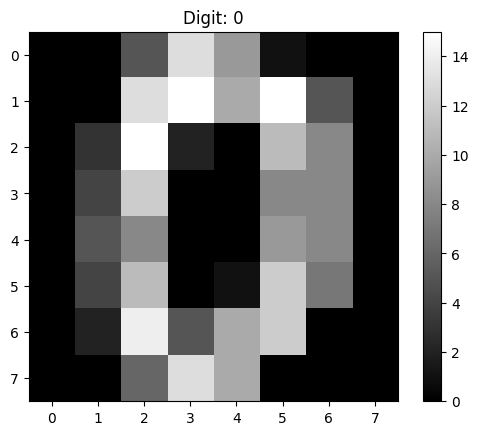

In [5]:
# Visualize the image at index=0

img_idx=0

plt.imshow(X[img_idx], cmap='gray')
plt.colorbar()
plt.title(f"Digit: {y[img_idx]}")
plt.show()

In [6]:
# Lets see the raw numbers
img_idx=0

print(X[img_idx].shape)
print("--------------------")
# np.set_printoptions(linewidth=150, precision=2, suppress=True)  # Adjust formatting
print(X[img_idx])

print("--------------------")

print(y[img_idx])


(8, 8)
--------------------
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
--------------------
0


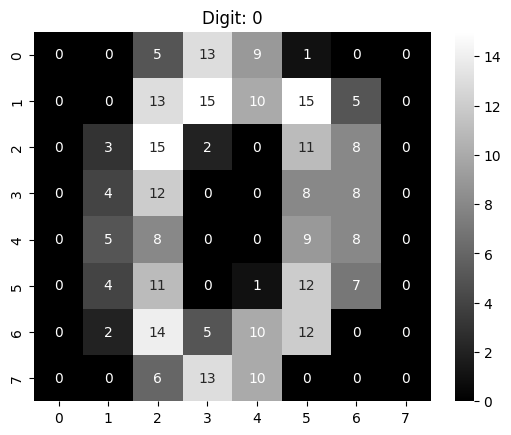

In [7]:
# Plot the pixel values on the image
img_idx = 0
img_matrix = X[img_idx]

# annot=True shows values, fmt="g" prevents scientific notation
sns.heatmap(img_matrix, annot=True, fmt="g", cmap="gray", cbar=True)
plt.title(f"Digit: {y[img_idx]}")
plt.show()


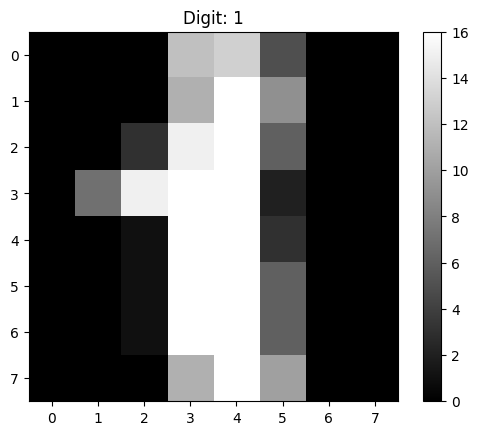

In [8]:
# Lets look at X[1], which is digit 1

img_idx=1

plt.imshow(X[img_idx], cmap='gray')
plt.colorbar()
plt.title(f"Digit: {y[img_idx]}")
plt.show()

In [9]:
# The raw values of the pixels are 
img_idx=1

print(X[img_idx].shape)
print("--------------------")
# np.set_printoptions(linewidth=150, precision=2, suppress=True)  # Adjust formatting
print(X[img_idx])

print("--------------------")

print(y[img_idx])

(8, 8)
--------------------
[[ 0.  0.  0. 12. 13.  5.  0.  0.]
 [ 0.  0.  0. 11. 16.  9.  0.  0.]
 [ 0.  0.  3. 15. 16.  6.  0.  0.]
 [ 0.  7. 15. 16. 16.  2.  0.  0.]
 [ 0.  0.  1. 16. 16.  3.  0.  0.]
 [ 0.  0.  1. 16. 16.  6.  0.  0.]
 [ 0.  0.  1. 16. 16.  6.  0.  0.]
 [ 0.  0.  0. 11. 16. 10.  0.  0.]]
--------------------
1


In [10]:
# Flatten the images if needed (convert 8x8 into 1D array of 64 pixels)
X = X.reshape(X.shape[0], -1)  # Converts (1797, 8, 8) -> (1797, 64)
print(X.shape)

(1797, 64)


In [11]:
#Lets see how does X[0] looks like now after reshape. It is 1D array, with 64 features, aka columns
print(X[0])

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


In [12]:
# Apply KMeans clustering: I am picking k=10 because I already the number of clusters

kmean = KMeans(n_clusters=10, random_state=42)
clusters = kmean.fit_predict(X)  # Clustering on the entire dataset


# Display the shape of the cluster centers
print(f"Cluster Centers Shape: {kmean.cluster_centers_.shape}")  # Should be (10, 64)

Cluster Centers Shape: (10, 64)


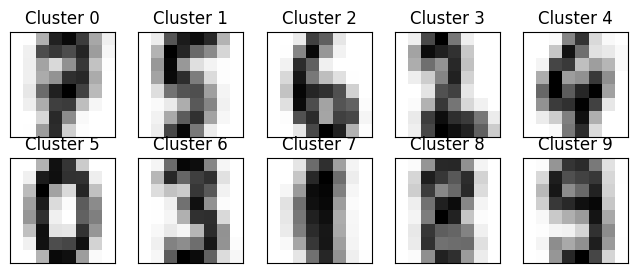

In [14]:
# We see ten clusters in 64 dimensions. 
# Let's visualize each of these cluster centers to see what they represent:
# I pick one digit from each clusters

import matplotlib.pyplot as plt

# Create a figure with a specified size (8 inches wide, 3 inches tall)
fig = plt.figure(figsize=(8, 3))  

# Loop through all 10 clusters found by KMeans
for i in range(10):
    # Add a subplot to the figure: a 2-row, 5-column grid 
    # '1 + i' ensures each image appears in the correct position
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])  

    # Reshape the i-th cluster center from 1D (64 pixels) back to 2D (8x8 image)
    # Use a grayscale colormap (binary) to display the image
    ax.imshow(kmean.cluster_centers_[i].reshape((8, 8)), cmap=plt.cm.binary)  

    # Add a title to each subplot showing the cluster number
    ax.set_title(f"Cluster {i}")

# Display the full figure with all the subplots
plt.show()


We see that *even without the labels*, KMeans is able to find clusters whose means are recognizable digits (with apologies to the number 8)!



Total images in cluster 0: 193


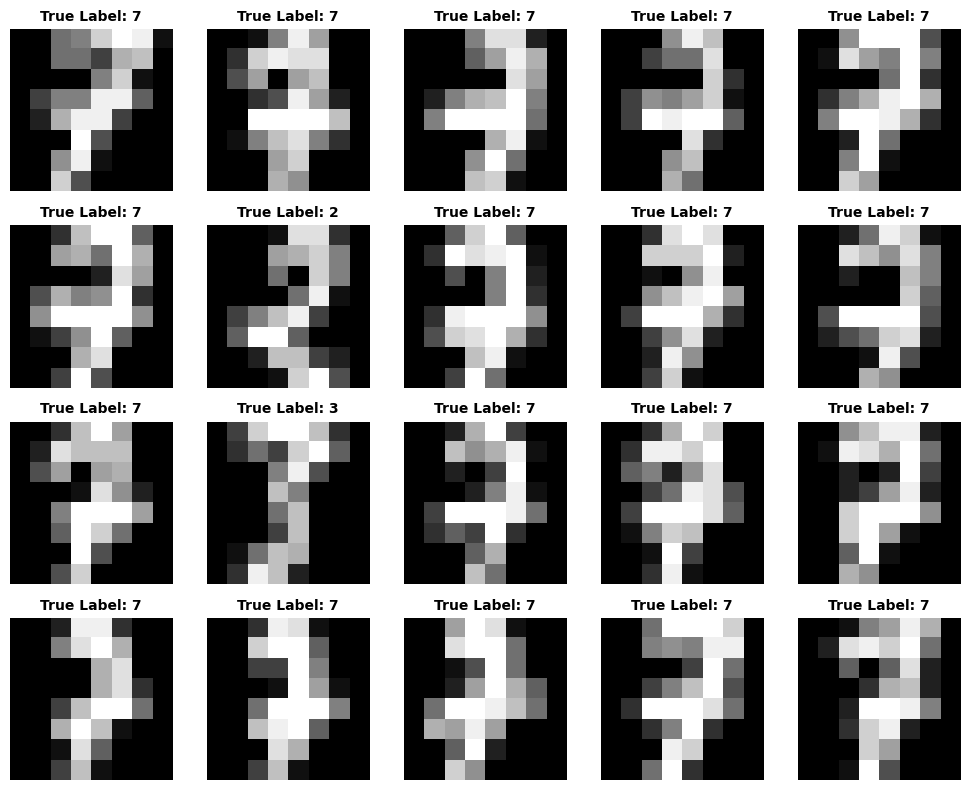

In [19]:
# Lets see all the images in cluster 0

# 1. Get the images and actual labels belonging only to cluster 0
cluster_N_images = X[clusters == 0]
cluster_N_labels = y[clusters == 0]
print(f"Total images in cluster 0: {len(cluster_N_images)}")


# 2. Define a grid layout (e.g., a 4x5 grid for the first 20 images)
rows, cols = 4, 5
fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    if i < len(cluster_N_images):
        # Reshape the flat 64-element vector back to 8x8
        img = cluster_N_images[i].reshape(8, 8)
        
        # Display the image
        ax.imshow(img, cmap='gray')
        
        # Plot the actual label from variable 'y' as the title
        ax.set_title(f"True Label: {cluster_N_labels[i]}", fontsize=10, weight='bold')
        
    ax.axis('off')  # Hide grid lines and axis numbers

plt.tight_layout()
plt.show()

# Observation: It seems 7

Total images in cluster 3: 173


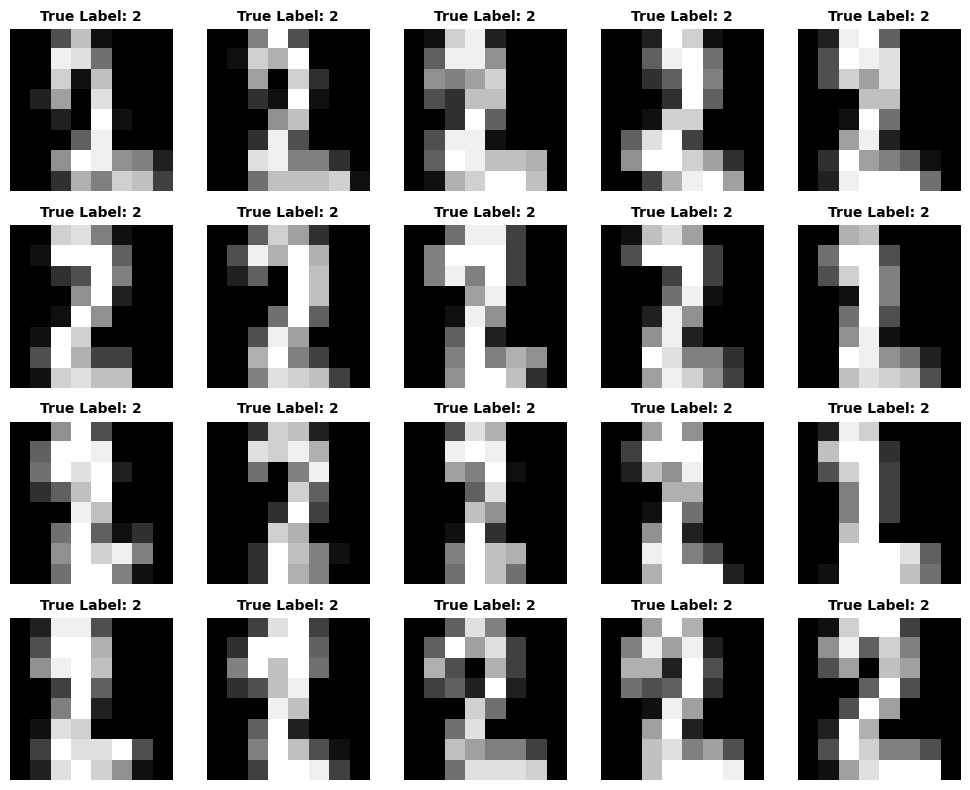

In [20]:
# Lets see all the images in cluster 3

# 1. Get the images and actual labels belonging only to cluster 0
cluster_N_images = X[clusters == 3]
cluster_N_labels = y[clusters == 3]
print(f"Total images in cluster 3: {len(cluster_N_images)}")


# 2. Define a grid layout (e.g., a 4x5 grid for the first 20 images)
rows, cols = 4, 5
fig, axes = plt.subplots(rows, cols, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    if i < len(cluster_N_images):
        # Reshape the flat 64-element vector back to 8x8
        img = cluster_N_images[i].reshape(8, 8)
        
        # Display the image
        ax.imshow(img, cmap='gray')
        
        # Plot the actual label from variable 'y' as the title
        ax.set_title(f"True Label: {cluster_N_labels[i]}", fontsize=10, weight='bold')
        
    ax.axis('off')  # Hide grid lines and axis numbers

plt.tight_layout()
plt.show()

# Observation: It seems 7

K-Means assigns arbitrary cluster labels, so Cluster 3 ≠ Digit 3.


# Following step maps clusters to the correct digit labels based on frequency.

## Example:

## Before Mapping: (Cluster Labels from K-Means)
Cluster Number->	Digits in Cluster

0->	7, 7, 7, 7, 7, 7, 2, 7, 7,

1->	5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5

2->	6, 6, 6, 6, 6, 6, 6, 6, 6, 6

...	...

## After Mapping: (Corrected Cluster Labels)
Cluster Number ->	Assigned Digit which is the most frequently occuring digit.

0->	7 (since 4 is the most frequent digit in cluster 0)

1->	5

2->	6

...	...

In other worrds, the cluster labels are permuted; following code fixes this:

In [21]:
# Print the digits belonging to each cluster
for i in range(10):  # For each cluster
    mask = (clusters == i)  # Get indices of data points belonging to cluster i
    digits_in_cluster = y[mask]  # Get the true labels (digits) of points in this cluster
    print(f"Cluster {i} contains the following digits: {digits_in_cluster}")

Cluster 0 contains the following digits: [7 7 7 7 7 7 2 7 7 7 7 3 7 7 7 7 7 7 7 7 7 7 7 7 7 3 7 7 7 9 7 9 7 7 7 7 7
 9 9 7 7 9 7 9 7 7 7 9 7 7 7 7 7 7 7 7 7 7 7 7 7 4 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 4 7 4 7 7 4 7 7 7 7 7 7 7 7 7 7 7 7 2 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 4 7 3 7 7 7 7 7 7 7 7 7 3 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 8 7 3 7 3 7 9 7 7 8 7 7 7 7 7 3
 7 7 7 7 7 7 7 7]
Cluster 1 contains the following digits: [5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 8 5 5 5 5 1 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 8 5 5 5 9 9 5 5 5 5 5 5 5 9 9 5 5 3 5 5 5 5 5 3 5]
Cluster 2 contains the following digits: [6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 1 6 6 6 6 1 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6
 6 6 6 6 8 6 6 6 6 6 6 6 6 6 6 6 6 6 

In [22]:
# Map each cluster to the most common actual digit
from scipy.stats import mode

# Map each cluster to the most common actual digit
cluster_to_digit = {}
for i in range(10):  # Loop through each cluster
    mask = (clusters == i)  # Get indices where cluster == i
    if np.sum(mask) > 0:  # Ensure the cluster is not empty
        most_common_digit = mode(y[mask], keepdims=True).mode[0]  # Fix IndexError by using keepdims=True
        cluster_to_digit[i] = most_common_digit
    else:
        cluster_to_digit[i] = None  # Handle empty clusters

# Print the mapping of clusters to digits
print("Cluster to Digit Mapping:")
for cluster, digit in cluster_to_digit.items():
    print(f"Cluster {cluster} → Digit {digit}")

Cluster to Digit Mapping:
Cluster 0 → Digit 7
Cluster 1 → Digit 5
Cluster 2 → Digit 6
Cluster 3 → Digit 2
Cluster 4 → Digit 4
Cluster 5 → Digit 0
Cluster 6 → Digit 3
Cluster 7 → Digit 1
Cluster 8 → Digit 8
Cluster 9 → Digit 9


# How many K-means got it right ?

In [23]:
from sklearn.metrics import accuracy_score

# Map predicted labels (clusters) to actual digit labels
predicted_labels = np.array([cluster_to_digit[cluster] for cluster in clusters])

# Calculate accuracy using accuracy_score
accuracy = accuracy_score(y, predicted_labels)

# Display the results
print(f"Clustering Accuracy: {accuracy * 100:.2f}%")

Clustering Accuracy: 86.14%


86% – not bad! Let's check-out the confusion matrix for this:

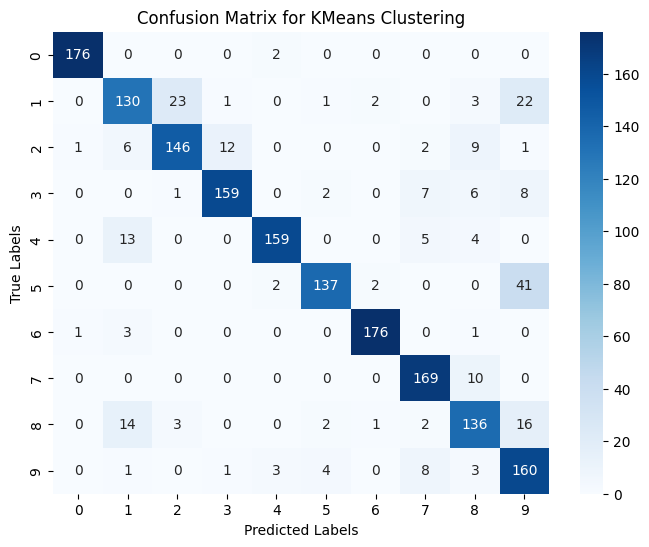

In [24]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y, predicted_labels)

# Plot the confusion matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix for KMeans Clustering")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

Again, this is an 80% classification accuracy for an **entirely unsupervised estimator** which knew nothing about the labels.

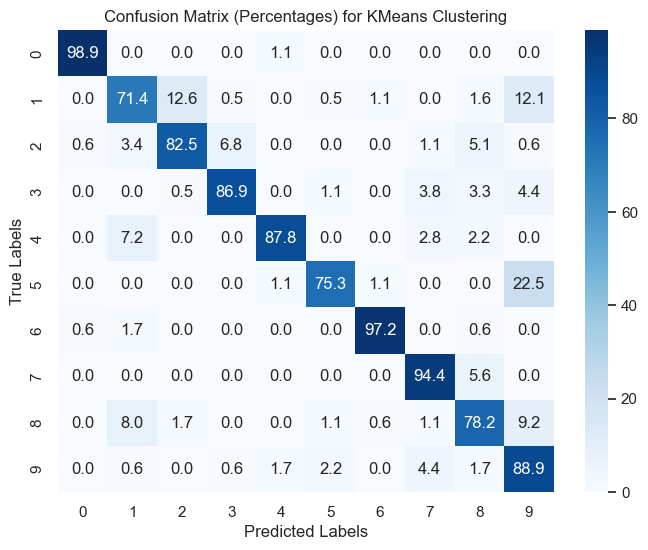

In [21]:
# I want to see percentage of above...

# Compute confusion matrix (rows = true labels, columns = predicted labels)
cm = confusion_matrix(y, predicted_labels)

# Normalize by row (i.e., true label count) to get percentages
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix (Percentages) for KMeans Clustering")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()
